# Assignment 3 — Use Case 1: Intelligent Customer Service Systems

## Person 3: Prompt Designer and LLM Manager

Name: Sagun Gurung

Student Id: 48930164

My role in this project is to design and evaluate the prompt-engineering and LLM response-generation component of the Intelligent Customer Service System.

This module integrates with:
- Person 1’s LLM backend and optional LoRA/fine-tuning experimentation
- Person 2’s NLP outputs: category classification, sentiment analysis, and named entity extraction
- Person 4’s RAG outputs: retrieved policy/FAQ context and escalation decision

The goal of this notebook is to generate polite, context-aware, useful, and policy-compliant customer service responses using a locally deployed LLM.

My contribution focuses on:
1. Selecting and integrating an appropriate LLM backend
2. Designing prompt templates for customer service response generation
3. Testing basic, structured, rag guided qwen prompt, Chain-of-Thought-inspired, and ReAct-style prompting strategies
4. Comparing prompt outputs using rule-based and LLM-assisted evaluation
5. Selecting the best-performing prompt design for final system integration
6. Preparing the final response-generation pipeline for UI integration by Person 5

## Importing Necessary Libraries

The notebook uses:

- `requests` to communicate with locally hosted LLM services such as Ollama.
- `pandas` to display comparison and evaluation tables.
- `time` to measure response generation time.
- `re` to extract structured evaluation scores from LLM-as-a-judge outputs.
- `os` to manage local file paths and LoRA adapter detection.
- `torch` to support local model execution and Apple Silicon GPU acceleration through MPS.

In [2]:
import requests
import pandas as pd
import time
import re
import os
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

In [3]:
# ============================================================
# Install required libraries for LoRA backend
# ============================================================
!pip install -q transformers accelerate peft bitsandbytes


## LLM Backend Setup for Prompt Engineering

The following code configures the LLM backend used for the prompt-engineering experiments and response-generation workflow in this notebook. Qwen2.5-1.5B-Instruct is used as the primary lightweight local model for testing prompt strategies, response quality, and final system integration.

The setup also supports optional LoRA adapter loading from Person 1’s model experimentation component. If the LoRA adapter is available, it can be attached to the base Qwen2.5-1.5B-Instruct model for improved task-specific behaviour. Otherwise, the notebook automatically falls back to the standard Qwen2.5-1.5B-Instruct model so the complete prompt-engineering pipeline can still be executed.

In addition, the code checks whether Apple Silicon GPU acceleration (MPS) is available on the local device and selects the appropriate execution backend for efficient local inference.

In [ ]:
# ============================================================
# LLM Backend Check: Qwen2.5-1.5B-Instruct + Optional LoRA Adapter
# ============================================================

BASE_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
LORA_WEIGHTS_PATH = "./lora-weights"

print("LLM backend:", BASE_MODEL_NAME)

if torch.cuda.is_available():
    device = "cuda"
    print("NVIDIA CUDA GPU acceleration available")
    print("GPU:", torch.cuda.get_device_name(0))

elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
    print("Apple Metal GPU acceleration available (MPS)")

else:
    device = "cpu"
    print("Running on CPU")

if os.path.exists(LORA_WEIGHTS_PATH):
    print("LoRA adapter found:", LORA_WEIGHTS_PATH)
else:
    print("LoRA adapter not found.")
    print("Notebook will fall back to base Qwen2.5-1.5B-Instruct model.")

LLM backend: Qwen/Qwen2.5-1.5B-Instruct
Apple Metal GPU acceleration available (MPS)
LoRA adapter found: ./lora-weights


## Input from Person 2

Since, Person 2 completed the basic NLP pipeline. Their `analyze()` function produces:

- cleaned text
- tokens
- POS tags
- named entities
- sentiment prediction
- category prediction

For my module, the most important fields are:

| Field | Used in my module |
|---|---|
| `customer_name` | Used for personalised greeting |
| `product` | Used to make the reply specific |
| `money` | Used when billing or invoice issue exists |
| `issue` | Used to identify the actual complaint |
| `sentiment` | Used to adjust tone |
| `category` | Used to guide response type |

The sample below is based on the real output received from Person 2.

In [5]:
customer_message = (
    "Hi my name is John, I ordered a MacBook Pro from Apple 3 days ago "
    "but it arrived damaged and I was charged $200 extra"
)

p2_analysis = {
    "clean_text": "hi john order macbook pro apple day ago arrive damage charge 200 extra",
    "tokens": [
        "hi", "john", "order", "macbook", "pro", "apple", "day", "ago",
        "arrive", "damage", "charge", "200", "extra"
    ],
    "pos_tags": [
        ("hi", "INTJ"),
        ("john", "PROPN"),
        ("ordered", "VERB"),
        ("macbook", "NOUN"),
        ("pro", "ADJ"),
        ("apple", "NOUN"),
        ("days", "NOUN"),
        ("ago", "ADV"),
        ("arrived", "VERB"),
        ("damaged", "VERB"),
        ("charged", "VERB"),
        ("200", "NUM"),
        ("extra", "ADJ")
    ],
    "entities": {
        "customer_name": ["John"],
        "product": ["macbook pro"],
        "shop": ["Apple"],
        "date": ["3 days ago"],
        "money": ["$200"],
        "issue": ["charged", "damaged"],
        "other": []
    },
    "sentiment": {
        "sentiment": "negative",
        "confidence": "52.5%"
    },
    "category": {
        "category": "INVOICE",
        "confidence": "keyword-based"
    }
}

print("Customer message:")
print(customer_message)

print("\nPerson 2 analysis:")
p2_analysis


Customer message:
Hi my name is John, I ordered a MacBook Pro from Apple 3 days ago but it arrived damaged and I was charged $200 extra

Person 2 analysis:


{'clean_text': 'hi john order macbook pro apple day ago arrive damage charge 200 extra',
 'tokens': ['hi',
  'john',
  'order',
  'macbook',
  'pro',
  'apple',
  'day',
  'ago',
  'arrive',
  'damage',
  'charge',
  '200',
  'extra'],
 'pos_tags': [('hi', 'INTJ'),
  ('john', 'PROPN'),
  ('ordered', 'VERB'),
  ('macbook', 'NOUN'),
  ('pro', 'ADJ'),
  ('apple', 'NOUN'),
  ('days', 'NOUN'),
  ('ago', 'ADV'),
  ('arrived', 'VERB'),
  ('damaged', 'VERB'),
  ('charged', 'VERB'),
  ('200', 'NUM'),
  ('extra', 'ADJ')],
 'entities': {'customer_name': ['John'],
  'product': ['macbook pro'],
  'shop': ['Apple'],
  'date': ['3 days ago'],
  'money': ['$200'],
  'issue': ['charged', 'damaged'],
  'other': []},
 'sentiment': {'sentiment': 'negative', 'confidence': '52.5%'},
 'category': {'category': 'INVOICE', 'confidence': 'keyword-based'}}

## Sample Input from Person 4 (for standalone testing)


Person 4 is responsible for RAG and escalation logic. Because this notebook focuses on Person 3, I use a temporary retrieved context and escalation decision to test my prompt module.

At this stage, I use a placeholder context so that my prompt-engineering module can be developed and tested independently. This is not my RAG implementation. It only simulates the type of input that Person 4 will later provide.

The placeholder includes:
- billing/invoice policy
- damaged product policy
- escalation rule

In [6]:
retrieved_context = """
Relevant company support policy:

1. Billing and invoice issue:
If a customer reports an incorrect charge, extra charge, or unrecognised payment,
the support assistant should apologise, ask for the order number, and request
a receipt or screenshot of the billing issue. The case should be reviewed by
the billing support team.

2. Damaged product issue:
If a product arrives damaged, the customer should be asked to provide the order
number and a photo of the damaged item. The support team can review the case
and provide the next steps for replacement, return, or refund options.

3. Escalation rule:
If the case involves both a damaged product and an incorrect charge, it should
be escalated to a human support agent for further review.
"""


escalation_decision = {
    "escalate": True,
    "reason": "The customer has negative sentiment, a damaged product, and an extra billing charge."
}

print(retrieved_context)
print(escalation_decision)



Relevant company support policy:

1. Billing and invoice issue:
If a customer reports an incorrect charge, extra charge, or unrecognised payment,
the support assistant should apologise, ask for the order number, and request
a receipt or screenshot of the billing issue. The case should be reviewed by
the billing support team.

2. Damaged product issue:
If a product arrives damaged, the customer should be asked to provide the order
number and a photo of the damaged item. The support team can review the case
and provide the next steps for replacement, return, or refund options.

3. Escalation rule:
If the case involves both a damaged product and an incorrect charge, it should
be escalated to a human support agent for further review.

{'escalate': True, 'reason': 'The customer has negative sentiment, a damaged product, and an extra billing charge.'}


## Helper Functions for Personalisation and Integration

Person 2's NER output includes `customer_name`. I use it to personalise the greeting.

Rule:

```text
If customer name exists → use "Dear [Name],"
If no customer name exists → use "Dear customer,"
```

Person 2's output may store `category` and `sentiment` as dictionaries, such as:

`{"category": "INVOICE", "confidence": "keyword-based"}`

or as simple strings, such as:

`"INVOICE"`

The helper functions handle both formats. They also extract the customer name, product, money amount, issues, and format the retrieved context from Person 4.

In [7]:
def get_category(p2_analysis):
    category = p2_analysis.get("category", "UNKNOWN")
    if isinstance(category, dict):
        return category.get("category", "UNKNOWN")
    return category


def get_sentiment(p2_analysis):
    sentiment = p2_analysis.get("sentiment", "neutral")
    if isinstance(sentiment, dict):
        return sentiment.get("sentiment", "neutral")
    return sentiment


def get_customer_name(p2_analysis):
    names = p2_analysis.get("entities", {}).get("customer_name", [])
    if isinstance(names, list) and len(names) > 0:
        return names[0]
    return "customer"


def get_customer_greeting(p2_analysis):
    name = get_customer_name(p2_analysis)
    if name != "customer":
        return f"Dear {name},"
    return "Dear customer,"

def get_order_number(p2_analysis):
    entities = p2_analysis.get("entities", {})
    order_numbers = entities.get("order_number", [])

    if order_numbers:
        return ", ".join(order_numbers)

    return "Not provided"

def join_entity_values(p2_analysis, key):
    values = p2_analysis.get("entities", {}).get(key, [])
    if isinstance(values, list) and len(values) > 0:
        return ", ".join(values)
    return "Not mentioned"


def format_retrieved_context(retrieved_context):
    if isinstance(retrieved_context, list):
        return "\n\n".join([str(item) for item in retrieved_context])

    if isinstance(retrieved_context, dict):
        return "\n\n".join([f"{key}: {value}" for key, value in retrieved_context.items()])

    return str(retrieved_context)


def format_escalation_decision(escalation_decision):
    if isinstance(escalation_decision, dict):
        escalate = escalation_decision.get("escalate", False)
        reason = escalation_decision.get("reason", "No reason provided")
        return f"Escalate: {escalate}. Reason: {reason}"

    if isinstance(escalation_decision, bool):
        return f"Escalate: {escalation_decision}"

    return str(escalation_decision)


In [8]:
# Testing Helper Functions
print("Greeting:", get_customer_greeting(p2_analysis))
print("Category:", get_category(p2_analysis))
print("Sentiment:", get_sentiment(p2_analysis))
print("Product:", join_entity_values(p2_analysis, "product"))
print("Money:", join_entity_values(p2_analysis, "money"))
print("Issues:", join_entity_values(p2_analysis, "issue"))


Greeting: Dear John,
Category: INVOICE
Sentiment: negative
Product: macbook pro
Money: $200
Issues: charged, damaged


## Function to recieve output from Person-2

The person 2's analyze() returns a dict.
The given below function validates and extracts only the fields that my prompt-building functions need. If any field is missing or malformed, it fills in a safe default so the prompts never crash.


In [9]:

def extract_p2_analysis(raw_p2_output):
    #  Entities
    raw_entities = raw_p2_output.get("entities", {})
    entity_keys = ["customer_name", "product", "shop", "date", "money", "issue", "other"]

    clean_entities = {}
    for key in entity_keys:
        value = raw_entities.get(key, [])
        # to ensure ir is in string format
        if isinstance(value, list):
            clean_entities[key] = [str(v) for v in value]
        else:
            clean_entities[key] = []

    # Sentiments
    raw_sentiment = raw_p2_output.get("sentiment", {})
    if isinstance(raw_sentiment, dict):
        sentiment_value = raw_sentiment.get("sentiment", "neutral")
        confidence_value = raw_sentiment.get("confidence", "unknown")
    elif isinstance(raw_sentiment, str):
        sentiment_value = raw_sentiment
        confidence_value = "unknown"
    else:
        sentiment_value = "neutral"
        confidence_value = "unknown"

    # Category
    raw_category = raw_p2_output.get("category", {})
    if isinstance(raw_category, dict):
        category_value = raw_category.get("category", "GENERAL")
        cat_confidence = raw_category.get("confidence", "unknown")
    elif isinstance(raw_category, str):
        category_value = raw_category
        cat_confidence = "unknown"
    else:
        category_value = "GENERAL"
        cat_confidence = "unknown"

    # --- Building clean output ---
    return {
        "clean_text": str(raw_p2_output.get("clean_text", "")),
        "tokens":     raw_p2_output.get("tokens", []),
        "pos_tags":   raw_p2_output.get("pos_tags", []),
        "entities":   clean_entities,
        "sentiment":  {"sentiment": sentiment_value,  "confidence": confidence_value},
        "category":   {"category":  category_value,   "confidence": cat_confidence}
    }


## Functions to take input from the Person 4

The below functions normalise Person 4's RAG/agent output. Person 4 may return retrieved context and escalation decisions using slightly different key names. These helper functions make my module flexible enough to accept those variations.

Person 4's run_part4_rag_agent() returns a dict. The key we need is 'retrieved_context_text' — a ready-to-use text block describing retrieved FAQ and policy entries.


In [10]:
def extract_p4_context(p4_output):
    retrieved_context_text = p4_output.get("retrieved_context_text", "")

    if not retrieved_context_text or retrieved_context_text.strip() == "":
        return "No relevant company FAQ or policy was retrieved."

    retrieved_context_text = retrieved_context_text.replace("[details to be confirmed]", "the relevant details")
    retrieved_context_text = retrieved_context_text.replace("[Your Name]", "Customer Support Team")
    retrieved_context_text = retrieved_context_text.replace("I've picked up that", "I understand that")
    retrieved_context_text = retrieved_context_text.replace("I've become conscious that", "I understand that")
    retrieved_context_text = retrieved_context_text.replace("I'm on your side your current situation", "I understand your current situation")

    return retrieved_context_text

def extract_escalation(p4_output):

    agent_output = p4_output.get("agent_output", {})

    # Pulling the escalate flag from nested escalation dict
    escalation_detail = agent_output.get("escalation", {})
    escalate_flag = escalation_detail.get("escalate", False)

    # Using agent reason as the human-readable reason
    reason = agent_output.get("reason", "No reason provided.")

    # Also accepting action-level override:
    # if agent action is explicitly ESCALATE_TO_HUMAN, always set escalate = True
    action = agent_output.get("action", "")
    if action == "ESCALATE_TO_HUMAN":
        escalate_flag = True

    return {
        "escalate": escalate_flag,
        "reason": reason
    }


## Prompt Engineering Strategy

This notebook compares several prompting techniques:

| Prompt | Purpose |
|---|---|
| Basic prompt | Baseline prompt using only customer message |
| Structured prompt | Uses Person 2 NLP output and Person 4 retrieved context |
| Few-shot prompt | Uses RAG context and strict rules for Qwen |
| Hidden CoT-inspired prompt | Guides internal step-by-step reasoning but only outputs final response |
| Visible CoT prompt | Shows step-by-step reasoning for analysis and marking evidence |
| ReAct-style prompt | Simulates Thought → Action → Observation → Answer using retrieved context |
| Instruction prompt | Uses strict numbered instructions |
| Preference prompt | Tells the model what type of output is preferred and what to avoid |

The goal is to compare how different prompt designs affect response quality.

## Prompt 1 — Basic Prompt

The basic prompt is used as a baseline. It only gives the customer message to the LLM.

Limitation: it does not explicitly use Person 2's category, sentiment, entities, or Person 4's retrieved policy context.

The below function is for comparison because it shows what happens when no structured NLP output, retrieved policy, or explicit rules are provided.

In [11]:
def build_basic_prompt(customer_message):
    """
    Baseline prompt — customer message only, no NLP or RAG context.
    Uses Qwen ChatML message list format.
    """
    system_content = (
        "You are a polite and professional customer service assistant. "
        "Your job is to write a single, helpful reply to the customer. "
        "Do not make unsupported promises. "
        "Always end your reply with exactly: Kind regards, Customer Support Team"
    )

    user_content = (
        f"A customer has sent the following message:\n\n"
        f"{customer_message}\n\n"
        f"Write a polite and professional customer service reply."
    )

    return [
        {"role": "system", "content": system_content},
        {"role": "user",   "content": user_content}
    ]


basic_prompt = build_basic_prompt(customer_message)
print(basic_prompt)

[{'role': 'system', 'content': 'You are a polite and professional customer service assistant. Your job is to write a single, helpful reply to the customer. Do not make unsupported promises. Always end your reply with exactly: Kind regards, Customer Support Team'}, {'role': 'user', 'content': 'A customer has sent the following message:\n\nHi my name is John, I ordered a MacBook Pro from Apple 3 days ago but it arrived damaged and I was charged $200 extra\n\nWrite a polite and professional customer service reply.'}]


## Prompt 2 — Structured Prompt

The structured prompt improves the baseline by adding system information:

- Person 2's predicted category,
- sentiment,
- extracted entities,
- Person 4's retrieved policy context,
- escalation decision.

This prompt is designed to make the response more specific, safer, and more relevant to the actual customer issue.


In [12]:
def build_structured_prompt(customer_message, p2_analysis, retrieved_context, escalation_decision):
    greeting = get_customer_greeting(p2_analysis)
    category = get_category(p2_analysis)
    sentiment = get_sentiment(p2_analysis)
    product = join_entity_values(p2_analysis, "product")
    money = join_entity_values(p2_analysis, "money")
    issues = join_entity_values(p2_analysis, "issue")
    retrieved_context_text = format_retrieved_context(retrieved_context)
    escalation_text = format_escalation_decision(escalation_decision)

    system_content = (
        "You are a polite and professional customer service assistant. "
        "You will be given a customer message, NLP analysis, retrieved company policy, and an escalation decision. "
        "Write a single customer-facing reply only. "
        "Do not explain your reasoning. "
        "Do not use placeholders like [Your Name] or [Order Number]. "
        "Always end with exactly: Kind regards, Customer Support Team"
    )

    user_content = (
        f"Customer message:\n{customer_message}\n\n"
        f"NLP analysis:\n"
        f"- Greeting to use: {greeting}\n"
        f"- Category: {category}\n"
        f"- Sentiment: {sentiment}\n"
        f"- Product: {product}\n"
        f"- Money mentioned: {money}\n"
        f"- Issues detected: {issues}\n"
        f"- Full entities: {p2_analysis.get('entities', {})}\n\n"
        f"Retrieved company policy:\n{retrieved_context_text}\n\n"
        f"Escalation decision:\n{escalation_text}\n\n"
        f"Instructions:\n"
        f"- Start with exactly: {greeting}\n"
        f"- If sentiment is negative, apologise clearly.\n"
        f"- Mention the product if available.\n"
        f"- Mention both the damaged product and extra charge if both are present.\n"
        f"- Do not invent order details.\n"
        f"- Do not promise an immediate refund.\n"
        f"- Ask for order number, billing screenshot or receipt, and photo of damaged product.\n"
        f"- If escalation is required, mention forwarding to the relevant support team.\n"
        f"- End with exactly: Kind regards, Customer Support Team"
    )

    return [
        {"role": "system", "content": system_content},
        {"role": "user",   "content": user_content}
    ]

## Prompt 3 — Few-shot Prompt

The Few-shot prompting gives the LLM examples of good responses before asking it to respond to the new customer. This helps guide tone, structure, and response rules.

The examples cover payment issues, damaged products, damaged products with extra charges, shipping delays, and cancellation requests. This helps the LLM follow a consistent customer service style.

In [13]:
def build_few_shot_prompt(customer_message, p2_analysis, retrieved_context, escalation_decision):
    greeting = get_customer_greeting(p2_analysis)
    customer_name = get_customer_name(p2_analysis)
    product = join_entity_values(p2_analysis, "product")
    money = join_entity_values(p2_analysis, "money")
    issues = join_entity_values(p2_analysis, "issue")

    system_content = (
        "You are a professional customer service assistant. "
        "You will be shown examples of good customer service replies, then asked to write one. "
        "Follow the tone, structure, and rules shown in the examples. "
        "Write a single customer-facing reply only. "
        "Do not use placeholders like [Your Name] or [Order Number]. "
        "Always end with exactly: Kind regards, Customer Support Team"
    )

    user_content = (
        f"Example 1:\n"
        f"Customer message: My payment failed but money was deducted from my account.\n"
        f"Good response:\n"
        f"Dear customer,\n"
        f"I am sorry for the inconvenience caused by the payment issue. "
        f"Please provide your order number and a screenshot or receipt of the transaction so our billing team can review it. "
        f"We will investigate and advise you on the next steps.\n"
        f"Kind regards, Customer Support Team\n\n"

        f"Example 2:\n"
        f"Customer message: The product I received is broken and I want a refund.\n"
        f"Good response:\n"
        f"Dear customer,\n"
        f"I am sorry to hear that your product arrived broken. "
        f"Please provide your order number and a photo of the damaged product so our support team can assess the case. "
        f"We can then guide you through the available return, replacement, or refund options.\n"
        f"Kind regards, Customer Support Team\n\n"

        f"Example 3:\n"
        f"Customer message: My order arrived damaged and I was charged extra.\n"
        f"Good response:\n"
        f"Dear customer,\n"
        f"I am sorry to hear that your order arrived damaged and that you were charged extra. "
        f"Please provide your order number, a photo of the damaged item, and a billing receipt or screenshot. "
        f"Because this involves both a product issue and a billing issue, it may need to be forwarded to the relevant support team.\n"
        f"Kind regards, Customer Support Team\n\n"

        f"Now write a reply for the following customer.\n\n"
        f"Customer message:\n{customer_message}\n\n"
        f"NLP analysis:\n"
        f"- Customer name: {customer_name}\n"
        f"- Greeting to use: {greeting}\n"
        f"- Category: {get_category(p2_analysis)}\n"
        f"- Sentiment: {get_sentiment(p2_analysis)}\n"
        f"- Product: {product}\n"
        f"- Money mentioned: {money}\n"
        f"- Issues detected: {issues}\n\n"
        f"Retrieved company policy:\n{retrieved_context}\n\n"
        f"Escalation decision:\n{escalation_decision}\n\n"
        f"Rules:\n"
        f"- Start with exactly: {greeting}\n"
        f"- Mention the damaged product and extra charge if both are present.\n"
        f"- Ask for order number, billing screenshot or receipt, and photo of the damaged product.\n"
        f"- Do not guarantee refund or replacement.\n"
        f"- Mention escalation or review if required.\n"
        f"- End with exactly: Kind regards, Customer Support Team"
    )

    return [
        {"role": "system", "content": system_content},
        {"role": "user",   "content": user_content}
    ]

## Prompt 4a - Hidden-Chain-of-Thought-inspired prompt

This prompt asks the model to internally reason through the problem before writing the final answer.

The reasoning is hidden because the live customer-facing system should only show the final polished response, not the model's internal reasoning.

In [14]:
def build_cot_hidden_prompt(customer_message, p2_analysis, retrieved_context, escalation_decision):
    greeting = get_customer_greeting(p2_analysis)

    system_content = (
        "You are a professional customer service assistant. "
        "Before writing your reply, think through the following steps internally:\n"
        "1. What is the customer's main problem?\n"
        "2. What is the customer's emotion?\n"
        "3. What policy information is relevant?\n"
        "4. Is escalation required?\n"
        "5. What missing information should be requested?\n"
        "Do not show this internal reasoning. "
        "Output only the final customer-facing reply. "
        "Always end with exactly: Kind regards, Customer Support Team"
    )

    user_content = (
        f"Customer message:\n{customer_message}\n\n"
        f"NLP analysis:\n"
        f"- Category: {get_category(p2_analysis)}\n"
        f"- Sentiment: {get_sentiment(p2_analysis)}\n"
        f"- Entities: {p2_analysis.get('entities', {})}\n\n"
        f"Retrieved policy:\n{retrieved_context}\n\n"
        f"Escalation decision:\n{escalation_decision}\n\n"
        f"Rules:\n"
        f"- Start with exactly: {greeting}\n"
        f"- Mention the damaged product and extra charge.\n"
        f"- Ask for order number, billing evidence, and product photo.\n"
        f"- Avoid unsupported promises.\n"
        f"- End with exactly: Kind regards, Customer Support Team"
    )

    return [
        {"role": "system", "content": system_content},
        {"role": "user",   "content": user_content}
    ]

## Prompt 4b - Visible Chain-of-Thought Prompt

The hidden CoT-inspired prompt is better for the final customer-facing system because it only returns the final reply. However, for the analysis, I also test a visible step-by-step reasoning prompt.

This visible CoT prompt asks the LLM to explicitly show:

1. the customer's problem
2. the customer's emotion
3. the relevant policy
4. missing information
5. the final customer response

This is used for analysis and evaluation only, not for live customer output.

In [15]:
def build_cot_visible_prompt(customer_message, p2_analysis, retrieved_context, escalation_decision):
    greeting = get_customer_greeting(p2_analysis)
    category = get_category(p2_analysis)
    sentiment = get_sentiment(p2_analysis)
    product = join_entity_values(p2_analysis, "product")
    money = join_entity_values(p2_analysis, "money")
    issues = join_entity_values(p2_analysis, "issue")
    retrieved_context_text = format_retrieved_context(retrieved_context)
    escalation_text = format_escalation_decision(escalation_decision)

    system_content = (
        "You are a professional customer service assistant. "
        "This prompt is used for analysis and evaluation only. "
        "Show a structured step-by-step analysis, then write the final customer-facing reply. "
        "Always end the final reply with exactly: Kind regards, Customer Support Team"
    )

    user_content = (
        f"Customer message:\n{customer_message}\n\n"
        f"NLP analysis:\n"
        f"- Category: {category}\n"
        f"- Sentiment: {sentiment}\n"
        f"- Product: {product}\n"
        f"- Money mentioned: {money}\n"
        f"- Issues: {issues}\n"
        f"- Entities: {p2_analysis.get('entities', {})}\n\n"
        f"Retrieved policy:\n{retrieved_context_text}\n\n"
        f"Escalation decision:\n{escalation_text}\n\n"
        f"Complete each step below:\n\n"
        f"Step 1 — Customer problem:\n"
        f"Briefly identify the product, issue, charge, and core complaint.\n\n"
        f"Step 2 — Customer emotion and tone:\n"
        f"Briefly explain the sentiment and required tone.\n\n"
        f"Step 3 — Relevant policy:\n"
        f"Briefly identify which policy applies and whether escalation is needed.\n\n"
        f"Step 4 — Missing information:\n"
        f"Briefly list what information the support team needs from the customer.\n\n"
        f"Step 5 — Final customer reply:\n"
        f"- Start with exactly: {greeting}\n"
        f"- Mention the product and extra charge if available.\n"
        f"- Ask for order number, billing screenshot or receipt, and photo of the damaged product.\n"
        f"- Do not guarantee refund or replacement.\n"
        f"- End with exactly: Kind regards, Customer Support Team"
    )

    return [
        {"role": "system", "content": system_content},
        {"role": "user",   "content": user_content}
    ]

## Prompt 5 - ReAct-style Prompt

ReAct means Reasoning and Acting. A full ReAct agent normally follows a loop such as:

`Thought → Action → Observation → Answer`

In this project, the real action step, which is retrieving information from a knowledge base, belongs to Person 4's RAG component. Therefore, here I haven't build a full ReAct agent. Instead, I use a ReAct-style prompt to demonstrate how the LLM can use Person 4's retrieved context as the observation.

This is a simulated ReAct-style prompt, not a full tool-using ReAct implementation.

In [16]:
def build_react_prompt(customer_message, p2_analysis, retrieved_context, escalation_decision):
    greeting = get_customer_greeting(p2_analysis)
    category = get_category(p2_analysis)
    sentiment = get_sentiment(p2_analysis)
    product = join_entity_values(p2_analysis, "product")
    money = join_entity_values(p2_analysis, "money")
    issues = join_entity_values(p2_analysis, "issue")
    retrieved_context_text = format_retrieved_context(retrieved_context)
    escalation_text = format_escalation_decision(escalation_decision)

    system_content = (
        "You are a customer service assistant that reasons before acting. "
        "You will be given a Thought, an Action, and an Observation. "
        "Use them to write the final customer-facing reply only. "
        "Do not repeat the Thought, Action, or Observation in your output. "
        "Always end with exactly: Kind regards, Customer Support Team"
    )

    user_content = (
        f"Thought: The customer has the following issue — category: {category}, "
        f"sentiment: {sentiment}, product: {product}, money: {money}, issues: {issues}.\n\n"
        f"Action: Retrieve relevant company policy and check escalation decision.\n\n"
        f"Observation:\n{retrieved_context_text}\n\n"
        f"Escalation decision:\n{escalation_text}\n\n"
        f"Customer message:\n{customer_message}\n\n"
        f"Now write the final customer-facing reply.\n"
        f"- Start with exactly: {greeting}\n"
        f"- Ask for order number, billing screenshot or receipt, and photo of damaged item.\n"
        f"- Do not guarantee refund or replacement.\n"
        f"- Mention review or escalation if required.\n"
        f"- End with exactly: Kind regards, Customer Support Team"
    )

    return [
        {"role": "system", "content": system_content},
        {"role": "user",   "content": user_content}
    ]

## Prompt 6 - Instruction Prompt

The instruction prompt uses strict numbered rules. It is useful when the system needs more control over the response format, tone, and safety constraints.

In [17]:
def build_instruction_prompt(customer_message, p2_analysis, retrieved_context, escalation_decision):
    greeting = get_customer_greeting(p2_analysis)
    product = join_entity_values(p2_analysis, "product")
    money = join_entity_values(p2_analysis, "money")
    issues = join_entity_values(p2_analysis, "issue")
    category = get_category(p2_analysis)
    sentiment = get_sentiment(p2_analysis)
    order_number = get_order_number(p2_analysis)

    system_content = (
        "You are a professional customer service assistant. "
        "Write ONE customer-facing reply only. "
        "Do not explain your reasoning. "
        "Do not mention internal system words like category, sentiment, entities, RAG, or escalation dictionary. "
        "Do not use placeholders like [Order Number], {{order_number}}, [Your Name], or ORDER_ID. "
        "Always end with exactly: Kind regards, Customer Support Team"
    )

    user_content = (
        f"Customer message:\n{customer_message}\n\n"
        f"Customer information:\n"
        f"- Greeting to use: {greeting}\n"
        f"- Category: {category}\n"
        f"- Sentiment: {sentiment}\n"
        f"- Product: {product}\n"
        f"- Money mentioned: {money}\n"
        f"- Issues detected: {issues}\n"
        f"- Order number: {order_number}\n\n"
        f"Retrieved support guidance:\n{retrieved_context}\n\n"
        f"Escalation decision:\n{escalation_decision}\n\n"
        f"Follow these rules strictly:\n"
        f"1. Start with exactly: {greeting}\n"
        f"2. Write only the final customer-facing reply. Do not explain your reasoning.\n"
        f"3. Keep the reply short and clear: 2 to 4 short paragraphs only.\n"
        f"4. If order number is not 'Not provided', use it naturally and do not ask for it again.\n"
        f"5. If order number is 'Not provided' and the issue involves an order, ask for it.\n"
        f"6. Follow the retrieved support guidance. If it asks for specific information, include those items.\n"
        f"7. If the issue is about a damaged or defective product, ask for a photo and short description of the damage.\n"
        f"8. If the issue is about a payment, charge, or billing problem, ask for a receipt or screenshot.\n"
        f"9. If the customer has a login or account problem, ask for the email address linked to the account.\n"
        f"10. If escalation is required, politely say the case may need to be forwarded to a human support agent.\n"
        f"11. Do not guarantee refund, replacement, cancellation, or compensation before review.\n"
        f"12. Do not say 'we guarantee', 'you will definitely receive a refund', or 'we take full responsibility'.\n"
        f"13. End with exactly: Kind regards, Customer Support Team"
    )

    return [
        {"role": "system", "content": system_content},
        {"role": "user",   "content": user_content}
    ]

## Prompt 7 - Preference Prompt

The preference prompt tells the model what kind of response is preferred and what should be avoided. This helps guide response quality without using only strict rules.

In [18]:
def build_preference_prompt(customer_message, p2_analysis, retrieved_context, escalation_decision):
    greeting = get_customer_greeting(p2_analysis)
    retrieved_context_text = format_retrieved_context(retrieved_context)
    escalation_text = format_escalation_decision(escalation_decision)

    system_content = (
        "You are a customer service assistant. "
        "Generate a response that matches the preferred style below.\n\n"
        "Preferred response style:\n"
        "- Use a personalised greeting if the customer name is available.\n"
        "- Be empathetic but concise.\n"
        "- Reference the customer's specific issue and product.\n"
        "- Follow the retrieved policy.\n"
        "- Ask for any missing evidence such as order number, receipt, or photo.\n"
        "- Avoid unsupported promises.\n"
        "- Mention escalation only when required.\n"
        "- End with the support team signature.\n\n"
        "Avoid:\n"
        "- Generic greeting when a name is available.\n"
        "- Long unnecessary explanation.\n"
        "- Promising refund or replacement immediately.\n"
        "- Inventing order status.\n"
        "- Using placeholders like [Your Name] or [Order Number].\n"
        "Always end with exactly: Kind regards, Customer Support Team"
    )

    user_content = (
        f"Greeting to use: {greeting}\n\n"
        f"Customer message:\n{customer_message}\n\n"
        f"NLP analysis:\n{p2_analysis}\n\n"
        f"Retrieved policy:\n{retrieved_context_text}\n\n"
        f"Escalation decision:\n{escalation_text}\n\n"
        f"Write the final customer reply now."
    )

    return [
        {"role": "system", "content": system_content},
        {"role": "user",   "content": user_content}
    ]

## LLM Calling Function

The `call_ollama()` function sends a prompt to the local Ollama API and returns the generated response from Llama 3.

The function includes two important generation parameters:

- `temperature`: controls randomness/creativity.
- `num_predict`: controls approximate response length.

In [19]:

try:
    from peft import PeftModel
    PEFT_AVAILABLE = True
except Exception as e:
    print("PEFT not available:", e)
    PEFT_AVAILABLE = False

BASE_MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
LORA_WEIGHTS_PATH = "./lora-weights"

_lora_tokenizer = None
_lora_model = None
_lora_backend_status = None


def _load_lora_backend():
    """
    Loads Qwen2.5-1.5B-Instruct once and attaches the LoRA adapter from ./lora-weights if possible.

    P5 fixes:
    1. Tokenizer is loaded from Qwen2.5-1.5B-Instruct base model, not lora-weights.
    2. LoRA adapter is attached separately.
    3. If LoRA adapter fails, P3 still runs using base Qwen2.5-1.5B-Instruct.
    """
    global _lora_tokenizer, _lora_model, _lora_backend_status

    if _lora_tokenizer is not None and _lora_model is not None:
        return _lora_tokenizer, _lora_model, _lora_backend_status

    use_lora = os.path.exists(LORA_WEIGHTS_PATH) and PEFT_AVAILABLE

    print("Loading tokenizer from base model:", BASE_MODEL_NAME)
    _lora_tokenizer = AutoTokenizer.from_pretrained(
        BASE_MODEL_NAME,
        use_fast=False,
        trust_remote_code=True
    )

    if _lora_tokenizer.pad_token is None:
        _lora_tokenizer.pad_token = _lora_tokenizer.eos_token

    print("Loading base model...")
    base_model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_NAME,
        torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
        device_map="auto" if torch.cuda.is_available() else None,
        low_cpu_mem_usage=True
    )

    if use_lora:
        try:
            print("Attaching LoRA adapter from:", LORA_WEIGHTS_PATH)
            _lora_model = PeftModel.from_pretrained(base_model, LORA_WEIGHTS_PATH)
            _lora_backend_status = "Qwen2.5-1.5B+ LoRA adapter"
        except Exception as e:
            print("LoRA adapter failed to load. Falling back to base Qwen2.5-1.5B-Instruct.")
            print("LoRA error:", e)
            _lora_model = base_model
            _lora_backend_status = "Base model fallback after LoRA error"
    else:
        if os.path.exists(LORA_WEIGHTS_PATH) and not PEFT_AVAILABLE:
            print("LoRA folder exists, but PEFT is not available. Using base Qwen2.5-1.5B-Instruct.")
        else:
            print("LoRA adapter folder not found. Using base Qwen2.5-1.5B-Instruct fallback.")

        _lora_model = base_model
        _lora_backend_status = "Base model fallback"

    _lora_model.eval()
    print("LLM backend ready:", _lora_backend_status)

    return _lora_tokenizer, _lora_model, _lora_backend_status


def call_ollama(prompt, model="qwen_lora", temperature=0.3, num_predict=300):
    """
    Sends a prompt to Qwen2.5-1.5B-Instruct using the correct ChatML format.
    Accepts either:
      - a raw string (wrapped into user message automatically)
      - a list of {"role": ..., "content": ...} dicts (used directly)
    """
    tokenizer, llm_model, backend_status = _load_lora_backend()

    # Build message list
    if isinstance(prompt, list):
        messages = prompt
    else:
        messages = [{"role": "user", "content": prompt}]

    # Applying Qwen's ChatML template
    formatted = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        formatted,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    )

    model_device = next(llm_model.parameters()).device
    inputs = {k: v.to(model_device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = llm_model.generate(
            **inputs,
            max_new_tokens=num_predict,
            do_sample=True,
            temperature=temperature,
            top_p=0.9,
            repetition_penalty=1.1,
            pad_token_id=tokenizer.eos_token_id
        )

    # Decode only the newly generated tokens (not the prompt)
    input_length = inputs["input_ids"].shape[1]
    generated_ids = outputs[0][input_length:]
    decoded = tokenizer.decode(generated_ids, skip_special_tokens=True)

    return decoded.strip()

## Comparing All the Prompt Versions

This section generates responses for all prompt versions and stores the results in a dataframe. This supports comparison across multiple LLM processing techniques.  

In [20]:
prompt_versions = {
    "Basic Prompt": build_basic_prompt(customer_message),
    "Structured Prompt": build_structured_prompt(customer_message, p2_analysis, retrieved_context, escalation_decision),
    "Few Shot prompt": build_few_shot_prompt(customer_message, p2_analysis, retrieved_context, escalation_decision),
    "Hidden CoT Prompt": build_cot_hidden_prompt(customer_message, p2_analysis, retrieved_context, escalation_decision),
    "Visible CoT Prompt": build_cot_visible_prompt(customer_message, p2_analysis, retrieved_context, escalation_decision),
    "ReAct-style Prompt": build_react_prompt(customer_message, p2_analysis, retrieved_context, escalation_decision),
    "Instruction Prompt": build_instruction_prompt(customer_message, p2_analysis, retrieved_context, escalation_decision),
    "Preference Prompt": build_preference_prompt(customer_message, p2_analysis, retrieved_context, escalation_decision)
}

outputs = []
for prompt_name, prompt_text in prompt_versions.items():
    start = time.time()
    try:
        response = call_ollama(prompt_text, model="qwen_lora")
        status = "Success"
    except Exception as e:
        response = f"LLM failed: {e}"
        status = "Failed"
    end = time.time()

    outputs.append({
        "prompt_type": prompt_name,
        "status": status,
        "response_time_seconds": round(end - start, 2),
        "response": response
    })

outputs_df = pd.DataFrame(outputs)
outputs_df


Loading tokenizer from base model: Qwen/Qwen2.5-1.5B-Instruct
Loading base model...
Attaching LoRA adapter from: ./lora-weights
LoRA adapter failed to load. Falling back to base Qwen2.5-1.5B-Instruct.
LoRA error: LoraConfig.__init__() got an unexpected keyword argument 'lora_ga_config'
LLM backend ready: Base model fallback after LoRA error


Starting from v4.46, the `logits` model output will have the same type as the model (except at train time, where it will always be FP32)


,prompt_type,status,response_time_seconds,response
0,Basic Prompt,Success,12.04,"Dear Mr. John,\n\nThank you for reaching out t..."
1,Structured Prompt,Success,5.47,"Dear John,\n\nI apologize for any inconvenienc..."
2,Few Shot prompt,Success,8.98,"Dear John,\n\nI apologize for any inconvenienc..."
3,Hidden CoT Prompt,Success,6.56,"Dear John,\n\nI apologize for the inconvenienc..."
4,Visible CoT Prompt,Success,10.07,"Dear John,\n\nI understand that you have encou..."
5,ReAct-style Prompt,Success,4.25,"Dear John,\n\nI apologize for any inconvenienc..."
6,Instruction Prompt,Success,4.20,"Dear John,\n\nI apologize for any inconvenienc..."
7,Preference Prompt,Success,11.11,"Dear John,\n\nThank you for reaching out to us..."


## Printing Each Response Clearly
This section prints the generated response for each prompt version one by one.

In [21]:
for item in outputs:
    print("=" * 100)
    print("PROMPT TYPE:", item["prompt_type"])
    print("STATUS:", item["status"])
    print("RESPONSE TIME:", item["response_time_seconds"], "seconds")
    print()
    print(item["response"])
    print()


PROMPT TYPE: Basic Prompt
STATUS: Success
RESPONSE TIME: 12.04 seconds

Dear Mr. John,

Thank you for reaching out to us regarding your recent experience with the MacBook Pro. We deeply regret that an issue of this nature occurred.

We understand how disappointing this situation must be for you, and we apologize for any inconvenience or additional cost incurred as a result. Our team will immediately investigate the circumstances surrounding your order to determine if there were any errors on our part in handling your delivery.

In the meantime, please know that we have initiated a review process to ensure that similar issues do not occur in the future. If you would like to proceed with returning the item or seeking compensation, we can assist you with that at no additional charge.

Please let us know what steps you'd prefer to take next so we can address your concerns promptly.

Thank you again for bringing this matter to our attention. We appreciate your patience and understanding dur

## Rule-Based Evaluation

To compare prompt outputs quantitatively, I created a rule-based scoring function. This function checks whether the generated response includes important customer service qualities:

1. personalised greeting
2. empathy or apology
3. product mention
4. billing or extra charge mention
5. damaged product mention
6. request for order number
7. request for evidence such as receipt, screenshot, or photo
8. escalation or review handling
9. no unsafe refund/replacement guarantee

The maximum score is 9.

In [22]:
def evaluate_response(response, p2_analysis, escalation_decision):
    response_lower = response.lower()
    score = 0
    comments = []

    greeting = get_customer_greeting(p2_analysis).lower()
    product = join_entity_values(p2_analysis, "product").lower()
    money = join_entity_values(p2_analysis, "money").lower()
    escalation_required = False

    if isinstance(escalation_decision, dict):
        escalation_required = escalation_decision.get("escalate", False)
    elif isinstance(escalation_decision, bool):
        escalation_required = escalation_decision

    # 1. Personalised greeting
    if greeting in response_lower:
        score += 1
        comments.append("Uses required greeting")
    else:
        comments.append("Missing required greeting")

    # 2. Empathy/apology
    if any(word in response_lower for word in ["sorry", "apologise", "apologize", "understand"]):
        score += 1
        comments.append("Includes empathy or apology")
    else:
        comments.append("Missing empathy or apology")

    # 3. Product mention
    if product != "not mentioned" and product in response_lower:
        score += 1
        comments.append("Mentions extracted product")
    else:
        comments.append("Does not mention extracted product")

    # 4. Billing/charge issue
    if any(word in response_lower for word in ["charge", "$200", "billing", "invoice", "extra"]):
        score += 1
        comments.append("Mentions billing/extra charge issue")
    else:
        comments.append("Does not mention billing/extra charge issue")

    # 5. Damaged product issue
    if any(word in response_lower for word in ["damaged", "damage", "broken", "photo"]):
        score += 1
        comments.append("Mentions damaged product issue")
    else:
        comments.append("Does not mention damaged product issue")

    # 6. Order number
    if "order number" in response_lower:
        score += 1
        comments.append("Asks for order number")
    else:
        comments.append("Does not ask for order number")

    # 7. Evidence request
    if any(word in response_lower for word in ["receipt", "screenshot", "photo"]):
        score += 1
        comments.append("Asks for evidence")
    else:
        comments.append("Does not ask for enough evidence")

    # 8. Escalation/review handling
    if escalation_required:
        if any(word in response_lower for word in ["escalate", "forward", "review", "support team", "billing team"]):
            score += 1
            comments.append("Handles escalation/review")
        else:
            comments.append("Missing escalation/review")
    else:
        score += 1
        comments.append("No escalation required")

    # 9. Avoids unsafe guarantees
    unsafe_phrases = ["guarantee a refund", "definitely refund", "guarantee replacement", "definitely replace"]
    if not any(phrase in response_lower for phrase in unsafe_phrases):
        score += 1
        comments.append("Avoids unsafe refund/replacement guarantee")
    else:
        comments.append("Contains unsafe guarantee")
    
    

    return score, comments


## Applying Rule-Based Evaluation to All Prompt Outputs

Here I apply the rule-based evaluation to all prompt outputs and stores the score and comments in a dataframe.

In [23]:
evaluation_results = []
for item in outputs:
    score, comments = evaluate_response(
        item["response"],
        p2_analysis,
        escalation_decision
    )

    evaluation_results.append({
        "prompt_type": item["prompt_type"],
        "rule_score_out_of_9": score,
        "response_time_seconds": item["response_time_seconds"],
        "comments": comments
    })

evaluation_df = pd.DataFrame(evaluation_results)
evaluation_df


,prompt_type,rule_score_out_of_9,response_time_seconds,comments
0,Basic Prompt,5,12.04,"[Missing required greeting, Includes empathy o..."
1,Structured Prompt,8,5.47,"[Uses required greeting, Includes empathy or a..."
2,Few Shot prompt,9,8.98,"[Uses required greeting, Includes empathy or a..."
3,Hidden CoT Prompt,9,6.56,"[Uses required greeting, Includes empathy or a..."
4,Visible CoT Prompt,8,10.07,"[Uses required greeting, Includes empathy or a..."
5,ReAct-style Prompt,9,4.25,"[Uses required greeting, Includes empathy or a..."
6,Instruction Prompt,6,4.20,"[Uses required greeting, Includes empathy or a..."
7,Preference Prompt,9,11.11,"[Uses required greeting, Includes empathy or a..."


## LLM-as-a-Judge Evaluation

In addition to the rule-based score, I used an LLM-as-a-judge evaluation as an advanced technique. The judge prompt asks Llama 3 to rate each response from 1 to 5 across five criteria:

1. empathy
2. relevance
3. use of provided information
4. safety
5. clarity

This provides a second automated evaluation method and supports comparison between prompt strategies.

In [71]:
def llm_judge_response(customer_message, response, model="qwen_lora"):
    system_content = """
You are an evaluator for customer service responses.

Use a score from 1-10 for each criterion.

Do not assign identical scores unless two responses are genuinely equivalent.

Rate:
Empathy
Relevance
Use of information
Safety
Clarity

Then calculate:
Overall = average of the five criteria

Return only:

Empathy: X
Relevance: X
Use of information: X
Safety: X
Clarity: X
Overall: X.X
Brief comment: ...
"""

    user_content = (
        f"Customer message:\n{customer_message}\n\n"
        f"Response to evaluate:\n{response}"
    )

    messages = [
        {"role": "system", "content": system_content},
        {"role": "user",   "content": user_content}
    ]

    return call_ollama(messages, model=model, temperature=0.1, num_predict=180)

In [72]:
judge_results = []

for item in outputs:
    if item["status"] == "Success":
        try:
            judge_output = llm_judge_response(customer_message, item["response"], model="qwen_lora")
        except Exception as e:
            judge_output = f"Judge failed: {e}"
    else:
        judge_output = "Skipped because generation failed"

    judge_results.append({
        "prompt_type": item["prompt_type"],
        "llm_judge_output": judge_output
    })

judge_df = pd.DataFrame(judge_results)
judge_df


,prompt_type,llm_judge_output
0,Basic Prompt,Empathy: 9\nRelevance: 8\nUse of information: ...
1,Structured Prompt,Empathy: 8\nRelevance: 7\nUse of information: ...
2,Few Shot prompt,Empathy: 8\nRelevance: 7\nUse of information: ...
3,Hidden CoT Prompt,Empathy: 8\nRelevance: 9\nUse of information: ...
4,Visible CoT Prompt,Empathy: 8\nRelevance: 7\nUse of information: ...
5,ReAct-style Prompt,Empathy: 7\nRelevance: 8\nUse of information: ...
6,Instruction Prompt,Empathy: 8\nRelevance: 9\nUse of information: ...
7,Preference Prompt,Empathy: 8\nRelevance: 7\nUse of information: ...


### Extracting the LLM Judge Score

The LLM judge returns text, so this helper function extracts the overall score and converts it into a numeric value for comparison.

In [73]:
# extracting the LLM Judge Score
def extract_overall_score(judge_text):
    match = re.search(r"Overall:\s*(\d+)", str(judge_text))
    if match:
        return int(match.group(1))
    return None


judge_df["llm_judge_overall"] = judge_df["llm_judge_output"].apply(extract_overall_score)
judge_df


,prompt_type,llm_judge_output,llm_judge_overall
0,Basic Prompt,Empathy: 9\nRelevance: 8\nUse of information: ...,6
1,Structured Prompt,Empathy: 8\nRelevance: 7\nUse of information: ...,7
2,Few Shot prompt,Empathy: 8\nRelevance: 7\nUse of information: ...,7
3,Hidden CoT Prompt,Empathy: 8\nRelevance: 9\nUse of information: ...,7
4,Visible CoT Prompt,Empathy: 8\nRelevance: 7\nUse of information: ...,7
5,ReAct-style Prompt,Empathy: 7\nRelevance: 8\nUse of information: ...,7
6,Instruction Prompt,Empathy: 8\nRelevance: 9\nUse of information: ...,7
7,Preference Prompt,Empathy: 8\nRelevance: 7\nUse of information: ...,7


In [74]:
for _, row in judge_df.iterrows():
    print("=" * 50)
    print("Prompt:", row["prompt_type"])
    print(row["llm_judge_output"])
    print()

Prompt: Basic Prompt
Empathy: 9
Relevance: 8
Use of information: 7
Safety: 6
Clarity: 5
Overall: 6.4
Brief comment: The response shows some empathy towards the customer's situation, acknowledges the inconvenience, and offers assistance without being overly aggressive. However, the use of information seems limited, and the safety aspect could be improved by providing more details about the investigation process. Clarity is generally good, but the tone could be clearer.

Prompt: Structured Prompt
Empathy: 8
Relevance: 7
Use of information: 6
Safety: 5
Clarity: 9
Overall: 7.0
Brief comment: The response shows some empathy towards the customer's situation, addresses their concerns directly, and provides clear instructions on how to proceed. However, there is room for improvement in terms of relevance and use of information, particularly regarding the specific details needed to resolve the issue. Clarity is good, but safety aspects could be emphasized more strongly.

Prompt: Few Shot prompt

### Combining Evaluation Results

This table combines rule-based scores, LLM judge scores, and response time so that prompt versions can be compared using both quantitative scoring and qualitative LLM judgement.

In [75]:
combined_eval_df = evaluation_df.merge(
    judge_df[["prompt_type", "llm_judge_overall", "llm_judge_output"]],
    on="prompt_type",
    how="left"
)

combined_eval_df


,prompt_type,rule_score_out_of_9,response_time_seconds,comments,llm_judge_overall,llm_judge_output
0,Basic Prompt,5,12.04,"[Missing required greeting, Includes empathy o...",6,Empathy: 9\nRelevance: 8\nUse of information: ...
1,Structured Prompt,8,5.47,"[Uses required greeting, Includes empathy or a...",7,Empathy: 8\nRelevance: 7\nUse of information: ...
2,Few Shot prompt,9,8.98,"[Uses required greeting, Includes empathy or a...",7,Empathy: 8\nRelevance: 7\nUse of information: ...
3,Hidden CoT Prompt,9,6.56,"[Uses required greeting, Includes empathy or a...",7,Empathy: 8\nRelevance: 9\nUse of information: ...
4,Visible CoT Prompt,8,10.07,"[Uses required greeting, Includes empathy or a...",7,Empathy: 8\nRelevance: 7\nUse of information: ...
5,ReAct-style Prompt,9,4.25,"[Uses required greeting, Includes empathy or a...",7,Empathy: 7\nRelevance: 8\nUse of information: ...
6,Instruction Prompt,6,4.20,"[Uses required greeting, Includes empathy or a...",7,Empathy: 8\nRelevance: 9\nUse of information: ...
7,Preference Prompt,9,11.11,"[Uses required greeting, Includes empathy or a...",7,Empathy: 8\nRelevance: 7\nUse of information: ...


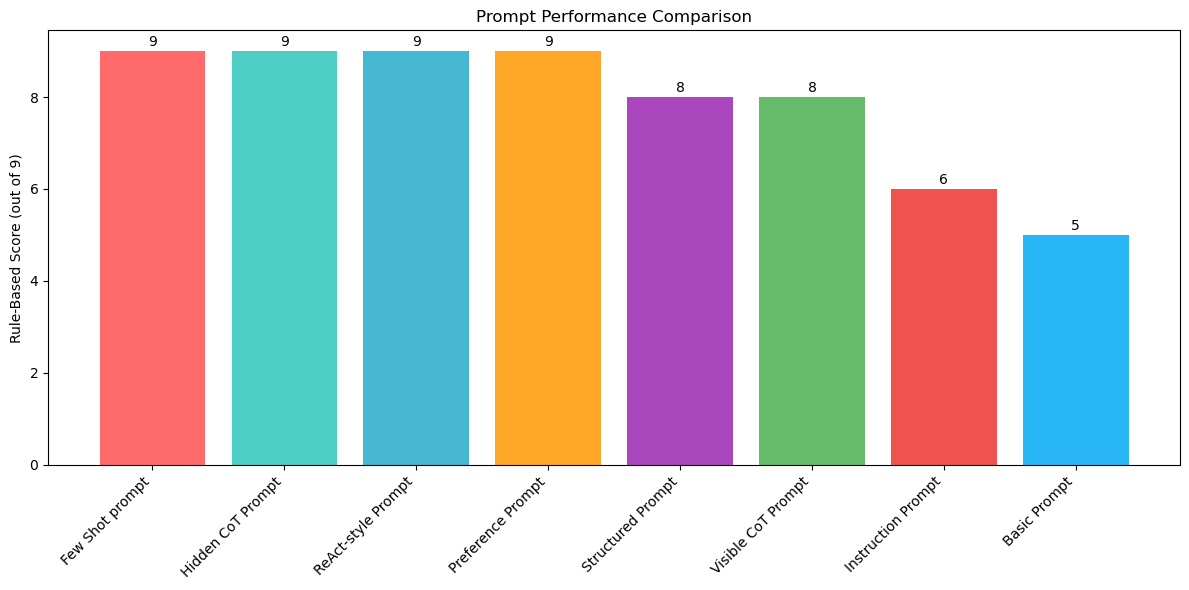

In [76]:
chart_df = combined_eval_df.sort_values(
    "rule_score_out_of_9",
    ascending=False
)

colors = [
    "#FF6B6B",
    "#4ECDC4",
    "#45B7D1",
    "#FFA726",
    "#AB47BC",
    "#66BB6A",
    "#EF5350",
    "#29B6F6"
]

plt.figure(figsize=(12,6))

bars = plt.bar(
    chart_df["prompt_type"],
    chart_df["rule_score_out_of_9"],
    color=colors
)

plt.title("Prompt Performance Comparison")
plt.ylabel("Rule-Based Score (out of 9)")
plt.xticks(rotation=45, ha="right")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        str(bar.get_height()),
        ha="center"
    )

plt.tight_layout()
plt.show()

## Selecting the Best Prompt

The best prompt is selected using the combined evaluation score. However, the final choice also considers customer-facing suitability.

Response time was included as an additional score out of 9 because this task is designed for a customer-service chatbot, where speed is an important part of the user experience. A response that is accurate but too slow may not be practical in a real support setting. Using a 9-point scale for response-time also keeps the response-time score consistent with the rule-based score, making the final combined score easier to compare across different prompt types. However, response time was not used by itself to select the best prompt, because quality, correctness, and customer-facing suitability were still the most important factors.

In [77]:
combined_eval_df["llm_judge_overall_filled"] = combined_eval_df["llm_judge_overall"].fillna(0)

# Response time is used as a small bonus score.
# Faster responses get a higher score, but quality still matters more than speed.
min_time = combined_eval_df["response_time_seconds"].min()
max_time = combined_eval_df["response_time_seconds"].max()

if max_time == min_time:
    combined_eval_df["response_time_score_out_of_9"] = 9
else:
    combined_eval_df["response_time_score_out_of_9"] = (
        9 * (max_time - combined_eval_df["response_time_seconds"]) / (max_time - min_time)
    ).round(9)

combined_eval_df["combined_score"] = (
    combined_eval_df["rule_score_out_of_9"] +
    combined_eval_df["llm_judge_overall_filled"] +
    combined_eval_df["response_time_score_out_of_9"]
)

prompt_ranking = combined_eval_df[
    [
        "prompt_type",
        "rule_score_out_of_9",
        "llm_judge_overall_filled",
        "response_time_seconds",
        "response_time_score_out_of_9",
        "combined_score"
    ]
].sort_values(
    by=["combined_score", "rule_score_out_of_9", "llm_judge_overall_filled", "response_time_score_out_of_9"],
    ascending=False
).reset_index(drop=True)

best_row = prompt_ranking.iloc[0]
best_prompt_type = best_row["prompt_type"]

prompt_ranking


,prompt_type,rule_score_out_of_9,llm_judge_overall_filled,response_time_seconds,response_time_score_out_of_9,combined_score
0,ReAct-style Prompt,9,7,4.25,8.942602,24.942602
1,Structured Prompt,8,7,5.47,7.542092,22.542092
2,Hidden CoT Prompt,9,7,6.56,6.290816,22.290816
3,Instruction Prompt,6,7,4.20,9.000000,22.000000
4,Few Shot prompt,9,7,8.98,3.512755,19.512755
5,Visible CoT Prompt,8,7,10.07,2.261480,17.261480
6,Preference Prompt,9,7,11.11,1.067602,17.067602
7,Basic Prompt,5,6,12.04,0.000000,11.000000


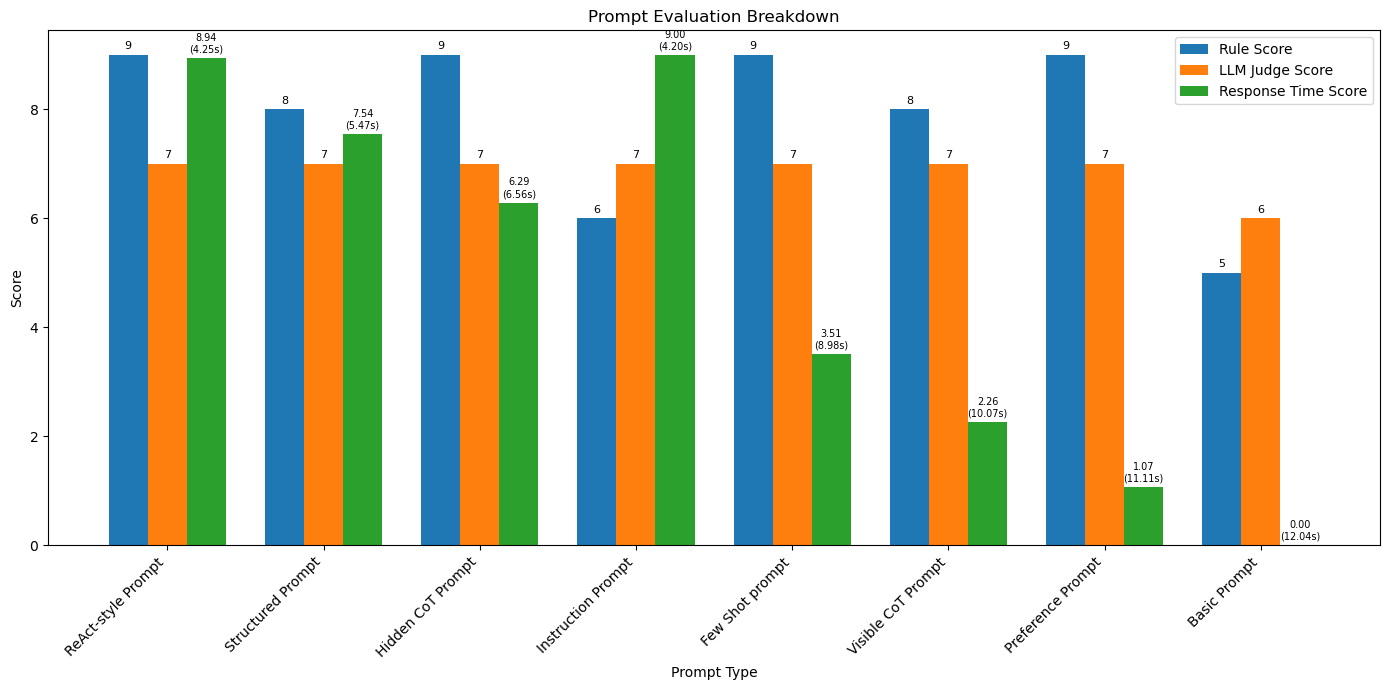

In [ ]:
import numpy as np

x = np.arange(len(prompt_ranking))
width = 0.25

plt.figure(figsize=(14, 7))

bars1 = plt.bar(
    x - width,
    prompt_ranking["rule_score_out_of_9"],
    width,
    label="Rule Score"
)

bars2 = plt.bar(
    x,
    prompt_ranking["llm_judge_overall_filled"],
    width,
    label="LLM Judge Score"
)

bars3 = plt.bar(
    x + width,
    prompt_ranking["response_time_score_out_of_9"],
    width,
    label="Response Time Score"
)

# Rule Score labels
for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.0f}",
        ha="center",
        fontsize=8
    )

# LLM Judge labels
for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.0f}",
        ha="center",
        fontsize=8
    )

# Response Time Score + actual seconds
for i, bar in enumerate(bars3):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.1,
        f"{bar.get_height():.2f}\n({prompt_ranking.iloc[i]['response_time_seconds']:.2f}s)",
        ha="center",
        fontsize=7
    )

plt.xticks(
    x,
    prompt_ranking["prompt_type"],
    rotation=45,
    ha="right"
)

plt.ylabel("Score")
plt.xlabel("Prompt Type")
plt.title("Prompt Evaluation Breakdown")
plt.legend()

plt.tight_layout()
plt.show()

In [87]:
best_row = prompt_ranking.iloc[0]
best_row

prompt_type                     ReAct-style Prompt
rule_score_out_of_9                              9
llm_judge_overall_filled                         7
response_time_seconds                         4.25
response_time_score_out_of_9              8.942602
combined_score                           24.942602
Name: 0, dtype: object

## Temperature Experiment

The model temperature controls how random or creative the response is. Lower temperature usually gives more predictable and consistent responses, while higher temperature may produce more varied but less controlled responses.

I tested the RAG-guided Qwen prompt using three temperature values:

- 0.1: very controlled
- 0.3: balanced and selected as the default
- 0.7: more creative but less predictable

This experiment helps justify the final model parameter choice.

In [80]:
react_prompt_temperature = build_react_prompt(
    customer_message,
    p2_analysis,
    retrieved_context,
    escalation_decision
)

temperature_results = []

for temp in [0.1, 0.3, 0.7]:
    try:
        response = call_ollama(
            react_prompt_temperature,
            model="qwen_lora",
            temperature=temp,
            num_predict=250
        )
        status = "Success"
    except Exception as e:
        response = f"Failed: {e}"
        status = "Failed"

    temperature_results.append({
        "temperature": temp,
        "status": status,
        "response": response
    })

temperature_df = pd.DataFrame(temperature_results)
temperature_df


,temperature,status,response
0,0.1,Success,"Dear John,\n\nI apologize for any inconvenienc..."
1,0.3,Success,"Dear John,\n\nI apologize for any inconvenienc..."
2,0.7,Success,"Dear John,\n\nThank you for reaching out about..."


## Evaluating Temperature Outputs

This section applies the same rule-based evaluation to the outputs generated at different temperature values. This helps decide whether the selected temperature produces controlled and complete customer service responses.

In [81]:
temperature_eval_results = []

for item in temperature_results:
    score, comments = evaluate_response(
        item["response"],
        p2_analysis,
        escalation_decision
    )

    temperature_eval_results.append({
        "temperature": item["temperature"],
        "rule_score_out_of_9": score,
        "comments": comments
    })

temperature_eval_df = pd.DataFrame(temperature_eval_results)
temperature_eval_df


,temperature,rule_score_out_of_9,comments
0,0.1,8,"[Uses required greeting, Includes empathy or a..."
1,0.3,8,"[Uses required greeting, Includes empathy or a..."
2,0.7,9,"[Uses required greeting, Includes empathy or a..."


## 12. Best Prompt Justification

Based on the rule-based evaluation and LLM-as-a-judge evaluation, the best-performing prompt was selected for final integration.

The RAG-guided Qwen prompt is a strong candidate because it gives the model examples of high-quality customer service responses. These examples help the model follow the correct tone, structure, and safety rules. The RAG-guided Qwen prompt also makes the response more consistent across different customer issues.

The visible CoT prompt is useful for analysis because it shows the reasoning steps. However, I believe it is not suitable for live customer-facing output because customers should only see the final polished response, not the internal reasoning process.

The ReAct-style prompt demonstrates the Thought → Action → Observation → Answer pattern, but it is not a full ReAct agent because the actual retrieval action belongs to Person 4's RAG system.

For the final system, the RAG-guided Qwen prompt was selected because it balances response quality, clarity, personalisation, and customer-facing suitability.

In [82]:
def generate_customer_reply(
    customer_message,
    p2_analysis,
    retrieved_context,
    escalation_decision,
    model="qwen_lora",
    temperature=0.1
):
    """
    My Final function for integration by Person 5.

    Inputs:
    - customer_message: raw customer query
    - p2_analysis: output from Person 2 analyze() function
    - retrieved_context: retrieved policy/FAQ context from Person 4
    - escalation_decision: escalation output from Person 4
    - model: Ollama model name
    - temperature: LLM generation temperature

    Output:
    - final customer service response
    """

    prompt = build_react_prompt(
        customer_message,
        p2_analysis,
        retrieved_context,
        escalation_decision
    )

    response = call_ollama(
        prompt,
        model=model,
        temperature=temperature,
        num_predict=250
    )

    return response


In [83]:
# testing the final customer response function
final_response = generate_customer_reply(
    customer_message,
    p2_analysis,
    retrieved_context,
    escalation_decision
)

print(final_response)


Dear John,

I apologize for any inconvenience this may have caused you. To assist us better, could you please provide me with the order number, a billing screenshot or receipt, and a photo of the damaged item? We'll need these details to proceed with the appropriate action.

Kind regards,  
Customer Support Team


## Final Function for UI Integration

This wrapper function is provided for Person 5. It accepts raw output from Person 2 and Person 4, normalises them using helper functions, and returns the final response along with the intermediate information.

This makes the module easier to plug into the final UI pipeline.

In [84]:

def final_response_for_UI(customer_message, raw_p2_output, raw_p4_output, model="qwen_lora", temperature=0.3):
    """
    Person 5 calls this function directly.

    result = final_response_for_UI(customer_message, raw_p2_output, raw_p4_output)

    Returns dict with keys:
        result["reply"]               — final customer-facing LLM response
        result["p2_analysis"]         — validated NLP analysis
        result["retrieved_context"]   — RAG context used by LLM
        result["escalation_decision"] — {"escalate": True/False, "reason": "..."}
    """

    # Step 1 — Validating and normalising the Person 2 output
    p2_analysis = extract_p2_analysis(raw_p2_output)

    # Step 2 — Extracting Person 4 context and escalation
    retrieved_context   = extract_p4_context(raw_p4_output)
    escalation_decision = extract_escalation(raw_p4_output)

    # Step 3 — Generating the final customer response
    reply = generate_customer_reply(
        customer_message,
        p2_analysis,
        retrieved_context,
        escalation_decision,
        model=model,
        temperature=temperature
    )

    return {
        "reply":               reply,
        "p2_analysis":         p2_analysis,
        "retrieved_context":   retrieved_context,
        "escalation_decision": escalation_decision
    }


## Integration Demo Using Sample Person 2 and Person 4 Outputs

This section demonstrates how Person 5 can call the full Person 3 pipeline after receiving outputs from Person 2 and Person 4.

In [85]:
customer_message = (
    "Hi my name is John, I ordered a MacBook Pro from Apple 3 days ago "
    "but it arrived damaged and I was charged $200 extra"
)

raw_p2_output = {
    "clean_text": "hi john order macbook pro apple day ago arrive damage charge 200 extra",
    "tokens": ["hi", "john", "order", "macbook", "pro", "apple", "day", "ago",
               "arrive", "damage", "charge", "200", "extra"],
    "pos_tags": [
        ("hi", "INTJ"), ("john", "PROPN"), ("ordered", "VERB"),
        ("macbook", "NOUN"), ("pro", "ADJ"), ("apple", "NOUN"),
        ("days", "NOUN"), ("ago", "ADV"), ("arrived", "VERB"),
        ("damaged", "VERB"), ("charged", "VERB"), ("200", "NUM"), ("extra", "ADJ")
    ],
    "entities": {
        "customer_name": ["John"],
        "product":       ["macbook pro"],
        "shop":          ["Apple"],
        "date":          ["3 days ago"],
        "money":         ["$200"],
        "issue":         ["charged", "damaged"],
        "other":         []
    },
    "sentiment": {"sentiment": "negative", "confidence": "52.5%"},
    "category":  {"category": "INVOICE",   "confidence": "keyword-based"}
}

# --- Real sample output from Person 4's run_part4_rag_agent() ---
raw_p4_output = {
    "retrieved_context_text": (
        "[Retrieved Item 1: Billing and Payment Policy | Type: manual_policy | "
        "Category: BILLING | Intent: billing_policy | Score: 0.821]\n"
        "Similar question: How should billing and duplicate charge issues be handled?\n"
        "Policy guidance: For duplicate charges, incorrect charges, or failed payments, "
        "customers should provide the order ID, transaction date, payment method, and "
        "charged amount. Possible overcharging should be reviewed by the billing team.\n\n"
        "[Retrieved Item 2: Damaged Product Policy | Type: manual_policy | "
        "Category: PRODUCT | Intent: damaged_product_policy | Score: 0.784]\n"
        "Similar question: What should happen if a product arrives damaged?\n"
        "Policy guidance: If a customer receives a damaged product, they should contact "
        "support within 7 days. They may be asked to provide photos of the damaged item, "
        "the order ID, and a short description of the damage."
    ),
    "agent_output": {
        "action": "ESCALATE_TO_HUMAN",
        "reason": "Negative sentiment detected for a serious customer service category.",
        "escalation": {
            "escalate":  True,
            "reasons":   ["Negative sentiment detected for a serious customer service category."],
            "sentiment": "negative",
            "category":  "invoice"
        }
    },
    "escalation_output": {
        "escalate": True,
        "reasons":  ["Negative sentiment detected for a serious customer service category."],
        "sentiment": "negative",
        "category":  "invoice"
    },
    "retrieved_context":  [],
    "dialogue_history":   []
}

# --- Running our pipeline ---
result = final_response_for_UI(customer_message, raw_p2_output, raw_p4_output)

# --- Show outputs ---
print("=== Validated P2 Analysis ===")
print("  Greeting  :", get_customer_greeting(result["p2_analysis"]))
print("  Sentiment :", result["p2_analysis"]["sentiment"]["sentiment"])
print("  Category  :", result["p2_analysis"]["category"]["category"])
print("  Product   :", join_entity_values(result["p2_analysis"], "product"))
print("  Money     :", join_entity_values(result["p2_analysis"], "money"))
print("  Issues    :", join_entity_values(result["p2_analysis"], "issue"))

print("\n=== Escalation Decision ===")
print(result["escalation_decision"])

print("\n=== Retrieved Context (first 300 chars) ===")
print(result["retrieved_context"][:300], "...")

print("\n=== Final Customer Reply ===")
print(result["reply"])


=== Validated P2 Analysis ===
  Greeting  : Dear John,
  Sentiment : negative
  Category  : INVOICE
  Product   : macbook pro
  Money     : $200
  Issues    : charged, damaged

=== Escalation Decision ===
{'escalate': True, 'reason': 'Negative sentiment detected for a serious customer service category.'}

=== Retrieved Context (first 300 chars) ===
[Retrieved Item 1: Billing and Payment Policy | Type: manual_policy | Category: BILLING | Intent: billing_policy | Score: 0.821]
Similar question: How should billing and duplicate charge issues be handled?
Policy guidance: For duplicate charges, incorrect charges, or failed payments, customers shoul ...

=== Final Customer Reply ===
Dear John,

I hope this message finds you well. I am writing to address your recent experience with your MacBook Pro purchase. Unfortunately, we have received feedback indicating that there were some issues with your order.

Could you please provide me with the order ID? Additionally, would you kindly share any b

## Self-Evaluation Report

As Person 3, my role was to design and evaluate the LLM response-generation component of the Intelligent Customer Service System. I used the structured output from Person 2's basic NLP pipeline, including category classification, sentiment analysis, POS tagging, and named entity extraction. I also designed my prompts so they can use the retrieved policy context and escalation decision from Person 4's RAG module.

My contribution included creating and comparing multiple prompt-engineering strategies: a basic prompt, a structured prompt, a RAG-guided Qwen prompt, a Chain-of-Thought-inspired prompt, and a ReAct-style prompt. These prompts were designed to guide the LLM to produce polite, relevant, personalised, and policy-aware customer service responses.

The notebook used Qwen2.5-1.5B-Instruct and Ollama-hosted LLMs for local response generation and prompt-engineering experiments. I did not build or train a large language model from scratch. Instead, my contribution focused on applying pretrained and optionally fine-tuned LLM backends through prompt engineering, structured prompting, and response evaluation.

My work was also designed to integrate with the backend model experimentation and LoRA-related implementation developed by Person 1. This integration allows the response-generation pipeline to remain compatible with locally hosted and lightweight LLM deployments while supporting future fine-tuning and model improvements.

I also implemented a rule-based evaluation function to compare generated responses based on use of the extracted customer name, empathy, product relevance, billing issue recognition, damaged product recognition, missing information requests, escalation handling, avoidance of unsafe promises, and professional closing.

The final output of my work is the `final_response_for_UI()` function. This function takes the customer message, Person 2 NLP analysis, Person 4 retrieved context, and escalation decision as input, and returns a final customer service response. This function is ready for Person 5 to integrate into the final user interface.

### LLM Choice Justification

Qwen2.5-1.5B-Instruct was selected as the main language model because it is a lightweight instruction-tuned foundation model that can run locally on consumer hardware. This made it suitable for a university project where the system needed to be demonstrated without relying on paid API access or external cloud services.

The project focuses on prompt engineering, LoRA adaptation, response evaluation, and integration with the full customer service pipeline rather than training a large model from scratch. Qwen2.5-1.5B-Instruct provides a practical balance between model size, response quality, and computational efficiency. Its instruction-tuned design also makes it suitable for generating structured customer service replies.

LoRA was used to adapt the model more efficiently without fully fine-tuning all model parameters. This reduced the computational cost while still allowing the model to be adjusted for the customer service response generation task. The final system combines the Qwen model with Part 2 NLP analysis and Part 4 RAG-based support guidance to generate more relevant and policy-aware responses.

While larger models may produce stronger responses, they require more memory, higher processing cost, or external API access. Therefore, Qwen2.5-1.5B-Instruct with LoRA was selected as a practical self-hosted solution for reproducible academic experimentation and system integration.

## Conclusion

This project demonstrated how prompt engineering can improve the quality, consistency, and safety of customer service responses generated by LLMs. My contribution focused on designing and evaluating multiple prompting strategies and integrating them with the broader intelligent customer service pipeline.

The final workflow combines:
- Person 1’s LLM backend and fine-tuning experimentation,
- Person 2’s NLP preprocessing pipeline,
- Person 4’s retrieval and escalation support,
- and Person 3’s prompt-engineered response generation system.

Together, these components form a modular AI customer service assistant capable of generating contextual, policy-aware, and professional customer responses suitable for future extension and interface integration.